In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from xgboost.callback import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"XGBoost version: {xgb.__version__}")

Libraries imported successfully!
XGBoost version: 3.2.0


In [2]:
print("Loading Covertype dataset... This may take a moment.")
covertype = fetch_openml('covertype', version=3, as_frame=True)

df = covertype.frame.copy()

print(f"Dataset shape: {df.shape}")
print(f"Number of features: {len(covertype.feature_names)}")
print(f"Target variable: {covertype.target_names}")

print("\nFirst 5 rows of the dataset:")
df.head()

Loading Covertype dataset... This may take a moment.
Dataset shape: (581012, 55)
Number of features: 54
Target variable: ['class']

First 5 rows of the dataset:


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,class
0,0.368684,0.141667,0.045455,0.184681,0.223514,0.071659,0.870079,0.913386,0.582677,0.875366,...,0,0,0,0,0,0,0,0,0,5
1,0.365683,0.155556,0.030303,0.151754,0.215762,0.054798,0.866142,0.925197,0.594488,0.867838,...,0,0,0,0,0,0,0,0,0,5
2,0.472736,0.386111,0.136364,0.191840,0.307494,0.446817,0.921260,0.937008,0.531496,0.853339,...,0,0,0,0,0,0,0,0,0,2
3,0.463232,0.430556,0.272727,0.173228,0.375969,0.434172,0.937008,0.937008,0.480315,0.865886,...,0,0,0,0,0,0,0,0,0,2
4,0.368184,0.125000,0.030303,0.109520,0.222222,0.054939,0.866142,0.921260,0.590551,0.860449,...,0,0,0,0,0,0,0,0,0,5


In [3]:
print("Basic information about the dataset:")
print(df.info())

Basic information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype   
---  ------                              --------------   -----   
 0   Elevation                           581012 non-null  float64 
 1   Aspect                              581012 non-null  float64 
 2   Slope                               581012 non-null  float64 
 3   Horizontal_Distance_To_Hydrology    581012 non-null  float64 
 4   Vertical_Distance_To_Hydrology      581012 non-null  float64 
 5   Horizontal_Distance_To_Roadways     581012 non-null  float64 
 6   Hillshade_9am                       581012 non-null  float64 
 7   Hillshade_Noon                      581012 non-null  float64 
 8   Hillshade_3pm                       581012 non-null  float64 
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  float64 
 10  Wilderness_Area1                    581012 

In [4]:
print("Missing values in the dataset:")
missing_values = df.isnull().sum()
print(f"Total missing values: {missing_values.sum()}")

print("\nTarget variable distribution:")
target_dist = df['class'].value_counts().sort_index()
print(target_dist)
print(f"\nNumber of classes: {len(target_dist)}")

Missing values in the dataset:
Total missing values: 0

Target variable distribution:
class
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64

Number of classes: 7


In [5]:
print(f"original dataset size:{df.shape}")
df_sample=df.sample(frac=0.3,random_state=42)
print(f"sampled dataset size:{df_sample.shape}")
print("\n Target variable distribution:")
target_dist=df_sample['class'].value_counts().sort_index()
print(target_dist)
print(f"\npercentage of classes in sample")
for i ,count in target_dist.items():
    percentage=(count/len(df_sample))*100
    print(f"class {i}:{percentage:.2f}%({count}samples)")

original dataset size:(581012, 55)
sampled dataset size:(174304, 55)

 Target variable distribution:
class
1    63556
2    85078
3    10638
4      795
5     2941
6     5227
7     6069
Name: count, dtype: int64

percentage of classes in sample
class 1:36.46%(63556samples)
class 2:48.81%(85078samples)
class 3:6.10%(10638samples)
class 4:0.46%(795samples)
class 5:1.69%(2941samples)
class 6:3.00%(5227samples)
class 7:3.48%(6069samples)


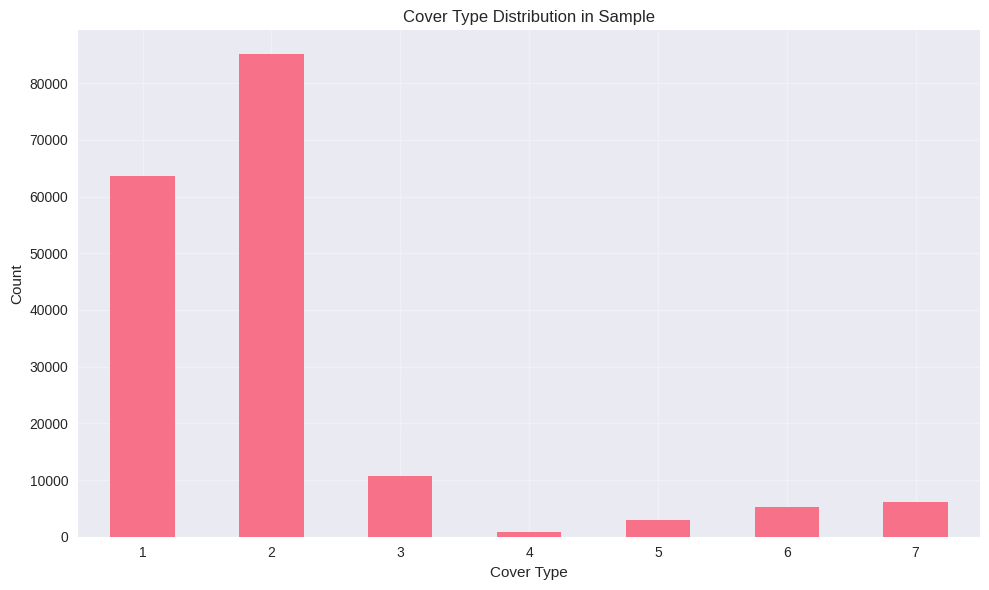

In [6]:
plt.figure(figsize=(10, 6))
target_dist.plot(kind='bar')
plt.title('Cover Type Distribution in Sample')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

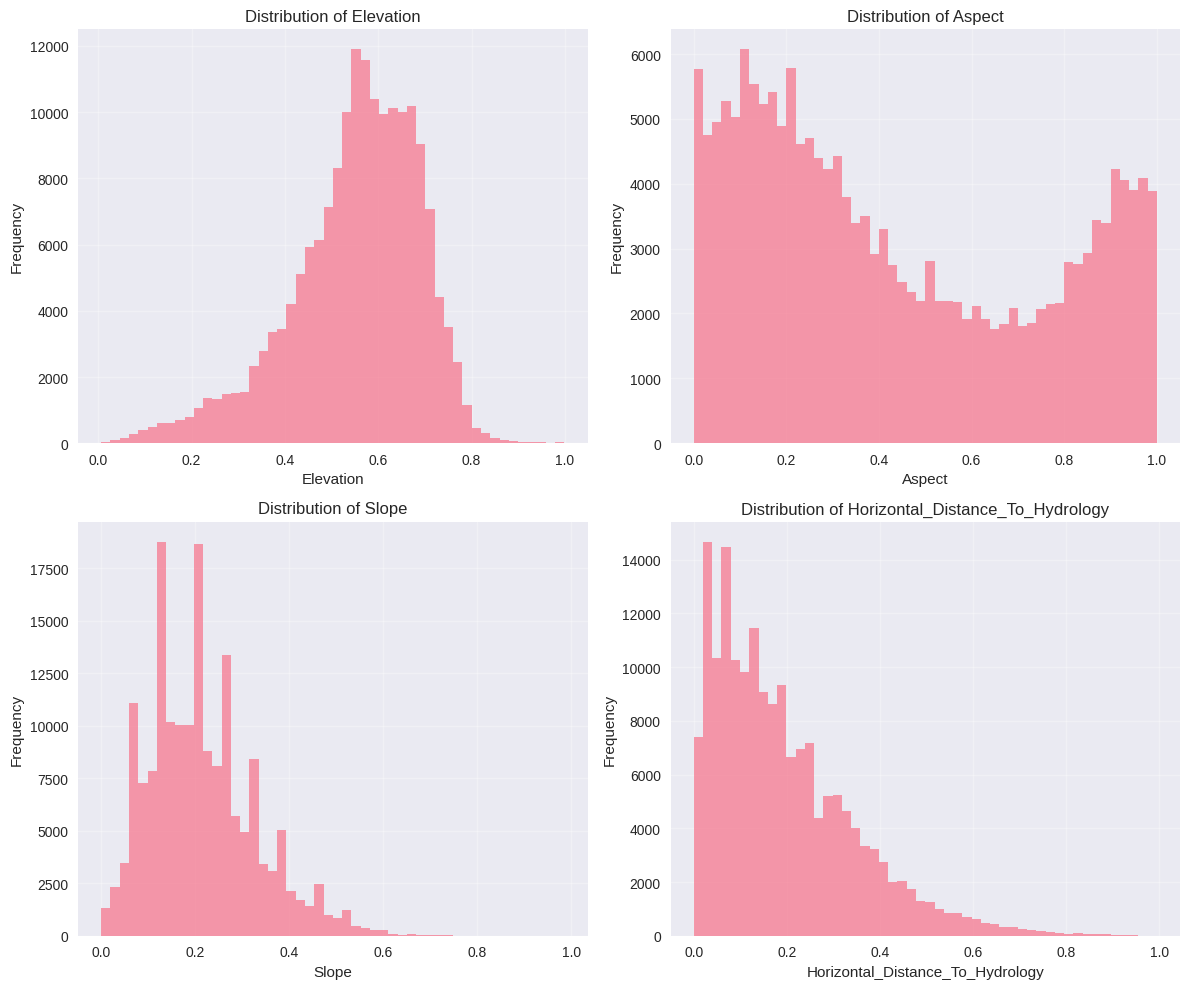

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features_to_plot = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology']

for i, feature in enumerate(features_to_plot):
    ax = axes[i//2, i%2]
    ax.hist(df_sample[feature], bins=50, alpha=0.7)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
xgb_classifier = xgb.XGBClassifier(n_estimators=100, max_depth=6,subsample=0.8,colsample_bytree=0.8,objective='multi:softprob',num_class=7,random_state=42, n_jobs=-1, enable_categorical=True)

print("Training")
xgb_classifier.fit(X_train, y_train_encoded)

print(" trained successfully!")
print(f"Number of  rounds: {xgb_classifier.n_estimators}")
print(f"Maximum depth: {xgb_classifier.max_depth}")

Training
 trained successfully!
Number of  rounds: 100
Maximum depth: 6


In [15]:
y_pred = xgb_classifier.predict(X_test)
y_pred_proba = xgb_classifier.predict_proba(X_test)

accuracy = accuracy_score(y_test_encoded, y_pred)

print("Model Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test_encoded, y_pred))

Model Performance Metrics:
Accuracy: 0.8642

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.85     12711
           1       0.86      0.89      0.88     17016
           2       0.89      0.90      0.89      2128
           3       0.81      0.75      0.78       159
           4       0.86      0.61      0.71       588
           5       0.83      0.82      0.82      1045
           6       0.94      0.88      0.91      1214

    accuracy                           0.86     34861
   macro avg       0.86      0.81      0.83     34861
weighted avg       0.86      0.86      0.86     34861



In [16]:
X = df_sample.drop('class', axis=1)
y = df_sample['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split successfully!
X_train shape: (139443, 54)
X_test shape: (34861, 54)
y_train shape: (139443,)
y_test shape: (34861,)


In [17]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Target variable encoded successfully!")

Target variable encoded successfully!


In [18]:
xgb_classifier = xgb.XGBClassifier(n_estimators=100, max_depth=6,subsample=0.8,colsample_bytree=0.8,objective='multi:softprob',num_class=7,random_state=42, n_jobs=-1, enable_categorical=True)

print("Training")
xgb_classifier.fit(X_train, y_train_encoded)

print(" trained successfully!")
print(f"Number of  rounds: {xgb_classifier.n_estimators}")
print(f"Maximum depth: {xgb_classifier.max_depth}")

Training
 trained successfully!
Number of  rounds: 100
Maximum depth: 6


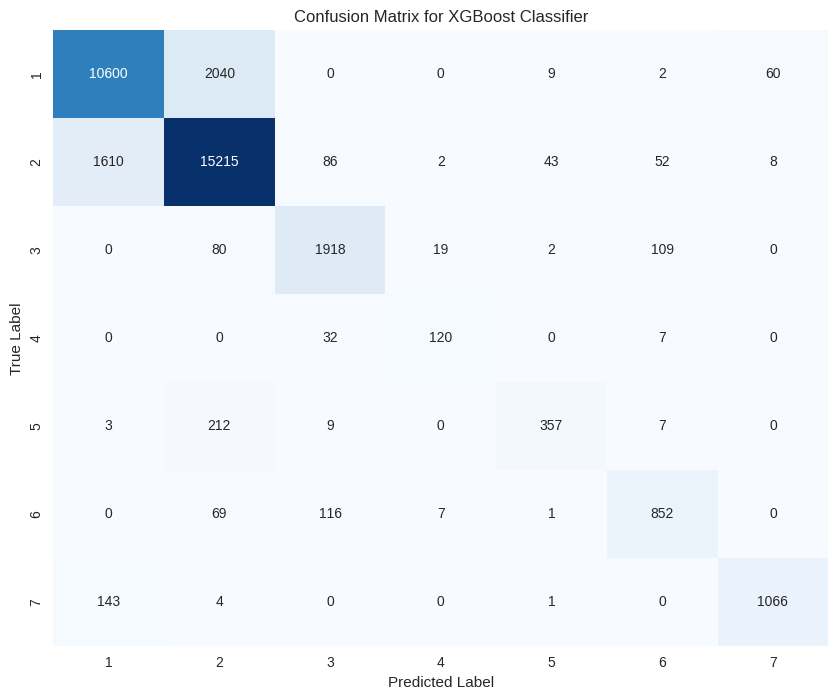

Per-Class Accuracy:
Class 1: 0.8339
Class 2: 0.8942
Class 3: 0.9013
Class 4: 0.7547
Class 5: 0.6071
Class 6: 0.8153
Class 7: 0.8781


In [19]:
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for XGBoost Classifier')
plt.show()

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("Per-Class Accuracy:")
for i, acc in enumerate(per_class_accuracy):
    print(f"Class {label_encoder.classes_[i]}: {acc:.4f}")

Top 10 Feature Importances (XGBoost):
             Feature  Importance
16        Soil_Type3    0.099717
0          Elevation    0.068035
52       Soil_Type39    0.049742
17        Soil_Type4    0.049435
35       Soil_Type22    0.045833
15        Soil_Type2    0.042091
25       Soil_Type12    0.039648
13  Wilderness_Area4    0.039267
12  Wilderness_Area3    0.036956
45       Soil_Type32    0.036866


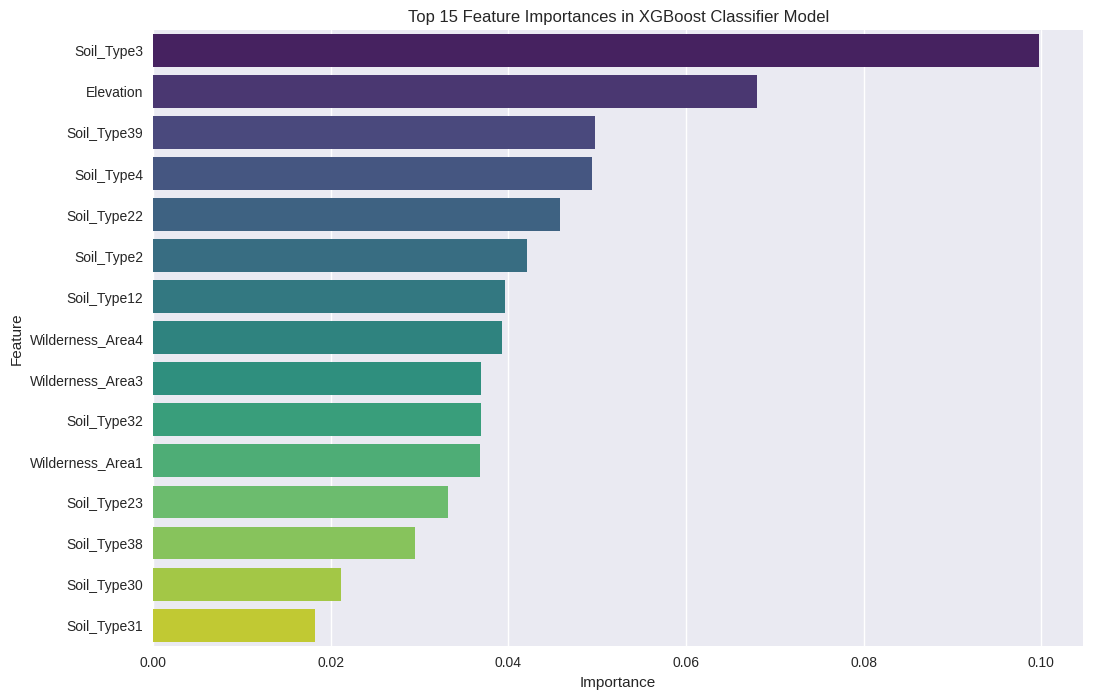

In [20]:
feature_importances_xgb = xgb_classifier.feature_importances_
feature_names_xgb = X_train.columns
importance_df_xgb = pd.DataFrame({'Feature': feature_names_xgb, 'Importance': feature_importances_xgb})
importance_df_xgb = importance_df_xgb.sort_values(by='Importance', ascending=False)
print("Top 10 Feature Importances (XGBoost):")
print(importance_df_xgb.head(10))
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df_xgb.head(15), palette='viridis')
plt.title('Top 15 Feature Importances in XGBoost Classifier Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

             Feature  Importance
16        Soil_Type3    0.099717
0          Elevation    0.068035
52       Soil_Type39    0.049742
17        Soil_Type4    0.049435
35       Soil_Type22    0.045833
15        Soil_Type2    0.042091
25       Soil_Type12    0.039648
13  Wilderness_Area4    0.039267
12  Wilderness_Area3    0.036956
45       Soil_Type32    0.036866


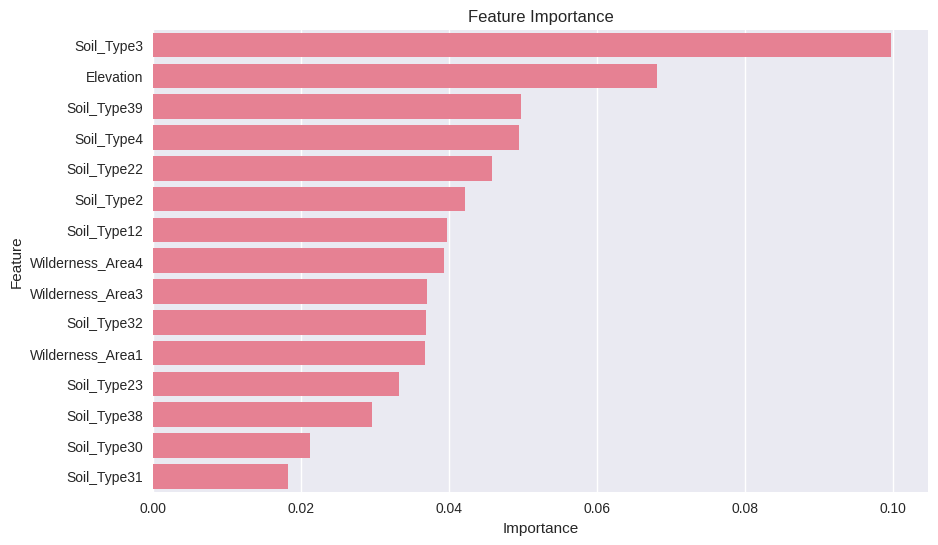

Top 2 most frequent classes:
class
1    63556
2    85078
Name: count, dtype: int64

Least frequent class:
class
6    5227
7    6069
Name: count, dtype: int64


In [21]:
X = df_sample.drop('class', axis=1)
y = df_sample['class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

xgb_classifier.fit(X_train, y_train_encoded)

feauture_importance = xgb_classifier.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feauture_importance}).sort_values('Importance', ascending=False)

print(feature_importance_df.head(10))
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Feature Importance')
plt.show()

class_counts = target_dist
top_two = class_counts.head(2)
least_one = class_counts.tail(2)

print("Top 2 most frequent classes:")
print(top_two)
print("\nLeast frequent class:")
print(least_one)

                               Feature  Importance
16                          Soil_Type3    0.099717
0                            Elevation    0.068035
52                         Soil_Type39    0.049742
17                          Soil_Type4    0.049435
35                         Soil_Type22    0.045833
15                          Soil_Type2    0.042091
25                         Soil_Type12    0.039648
13                    Wilderness_Area4    0.039267
12                    Wilderness_Area3    0.036956
45                         Soil_Type32    0.036866
10                    Wilderness_Area1    0.036752
36                         Soil_Type23    0.033251
51                         Soil_Type38    0.029514
43                         Soil_Type30    0.021204
44                         Soil_Type31    0.018240
11                    Wilderness_Area2    0.017814
42                         Soil_Type29    0.014925
53                         Soil_Type40    0.014887
34                         Soil

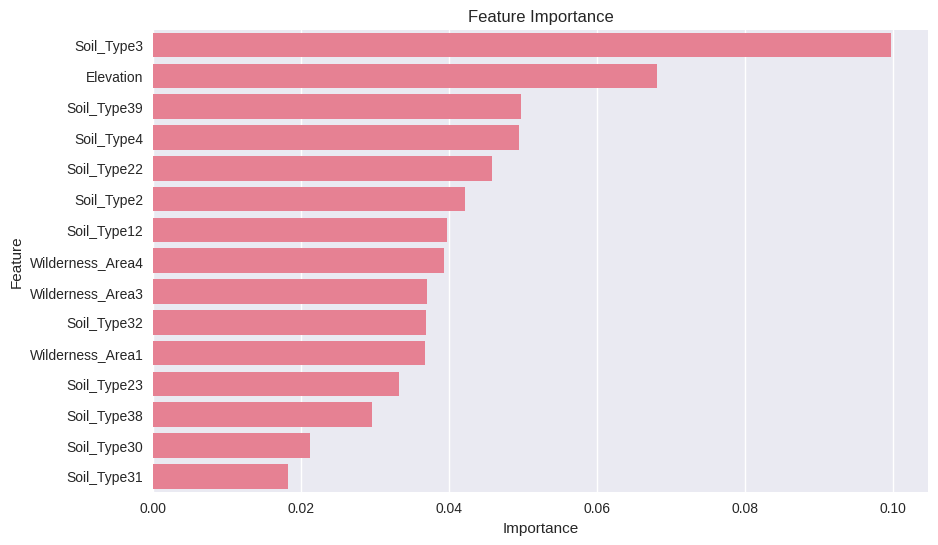

Top 2 most frequent classes:
class
1    63556
2    85078
Name: count, dtype: int64

Least frequent class:
class
6    5227
7    6069
Name: count, dtype: int64


In [22]:
feauture_importance = xgb_classifier.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feauture_importance}).sort_values('Importance',ascending=False)

print(feature_importance_df)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15))
plt.title('Feature Importance')
plt.show()
top_two = class_counts.head(2)
least_one = class_counts.tail(2)

print("Top 2 most frequent classes:")
print(top_two)
print("\nLeast frequent class:")
print(least_one)

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print(f"Accuracy of XGBoost : {accuracy:.4f}")

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train_encoded)

y_pred = rf_model.predict(X_test)

print(f"Accuracy of random forest: ", accuracy_score(y_test_encoded, y_pred))

Accuracy of XGBoost : 0.8642
Accuracy of random forest:  0.7508964171997361


Training with different max_depth values:
Accuracy with max_depth=3: 0.7438971917041967
Accuracy with max_depth=6: 0.8089555663922435
Accuracy with max_depth=9: 0.8725796735607125


<Axes: xlabel='max_depth', ylabel='accuracy'>

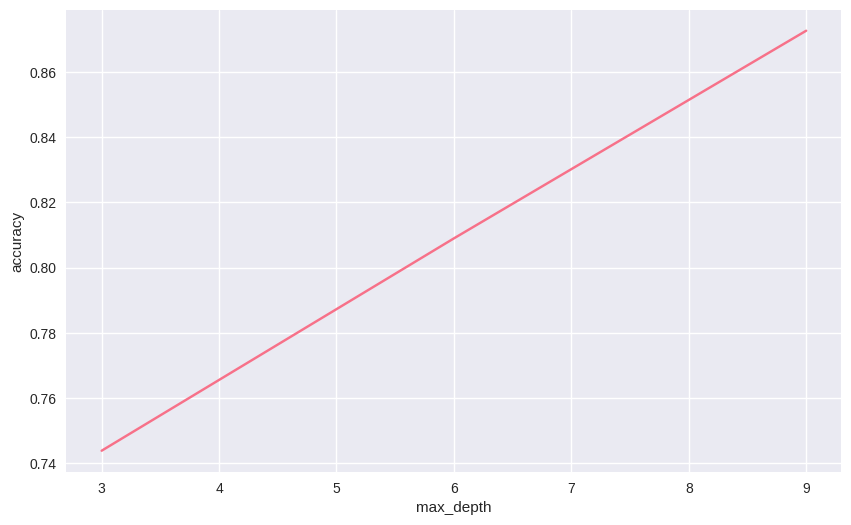

In [25]:
max_depth_values = [3,6,9]
results=[]
print("Training with different max_depth values:")
for depth in max_depth_values:
    xgb_classifier = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=depth,
        subsample=0.8,
        colsample_bytree=0.8,
        learning_rate=0.1,
        objective='multi:softprob',
        num_class=7,
        random_state=42,
        n_jobs=-1,
        enable_categorical=True
    )
    xgb_classifier.fit(X_train, y_train_encoded)
    accuracy=xgb_classifier.score(X_test,y_test_encoded)
    results.append(accuracy)
    print(f"Accuracy with max_depth={depth}: {accuracy}")
results_df=pd.DataFrame({'max_depth':max_depth_values,'accuracy':results})
plt.figure(figsize=(10,6))
sns.lineplot(x='max_depth',y='accuracy',data=results_df)

In [26]:
from sklearn.ensemble import RandomForestClassifier
print("training Random Forest Classifier...")
rf_classifier=RandomForestClassifier(n_estimators=100,random_state=42,max_depth=10,n_jobs=-1)
rf_classifier.fit(X_train,y_train_encoded)

y_pred_xgb=xgb_classifier.predict(X_test)
y_pred_rf=rf_classifier.predict(X_test)

xgb_accuracy=accuracy_score(y_test_encoded,y_pred_xgb)
rf_accuracy=accuracy_score(y_test_encoded,y_pred_rf)

print("model comparision")
print(f"XGBoost Accuracy:{xgb_accuracy:.4f}")
print(f"Random Forest Accuracy:{rf_accuracy:.4f}")

if xgb_accuracy > rf_accuracy:
    print(f"Improvement: {xgb_accuracy - rf_accuracy:.4f} ({(xgb_accuracy - rf_accuracy) / rf_accuracy:.2%})")
elif rf_accuracy > xgb_accuracy:
    improvement_percentage = (rf_accuracy - xgb_accuracy) / xgb_accuracy if xgb_accuracy != 0 else float('inf')
    print(f"Improvement: {rf_accuracy - xgb_accuracy:.4f} ({improvement_percentage:.2%})")
else:
    print("Both models have the same accuracy.")

training Random Forest Classifier...
model comparision
XGBoost Accuracy:0.8726
Random Forest Accuracy:0.7509
Improvement: 0.1217 (16.21%)
